# Executive Summary

This notebook analysed the CBS dataset 85918NED, covering labour market developments in the Netherlands between 1995 and 2024. The dataset provides labour indicators such as employment, number of jobs, labour volume (FTE), and hours worked across industry sectors, gender, and worker types.

The analysis shows that the Dutch labour market has experienced steady long-term growth, accompanied by a structural shift toward service-oriented sectors, particularly healthcare and business services. Female labour participation increased significantly over the period, contributing to changes in workforce composition across several sectors.

Sectoral analysis also revealed strong differences in labour intensity and employment structures. Male-dominated sectors such as construction and energy tend to have predominantly full-time employment, while sectors with higher female participation, such as healthcare and education, show higher prevalence of part-time work.

These structural labour market patterns provide valuable macro-level context for future modelling work, as sector composition, gender participation, and labour intensity may influence workforce behaviour and absenteeism dynamics.

# Cleaning 85918NED Data



## 1. Import required libraries

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Reading the table from Silver Database

In [2]:
from pathlib import Path
import sqlite3
import pandas as pd

# Path to the silver database
db_path = Path("../../data/2_silver/silver_data.db")

# Connect to the database
conn = sqlite3.connect(db_path)
print(f"Connected to {db_path}")

# List available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print("Available tables:", tables["name"].tolist())

# Read the table (IMPORTANT: quote table name because it starts with a number)
table_name = "85918NED_silver"

df_85918NED = pd.read_sql_query(
    f'SELECT * FROM "{table_name}"',
    conn
)

print(f"Loaded {len(df_85918NED)} rows from {table_name}")
display(df_85918NED.head())

# 1️⃣ Column names
print(df_85918NED.columns.tolist())

# 2️⃣ Data types
print(df_85918NED.dtypes)

# 3️⃣ Compact summary (best overview)
df_85918NED.info()

# 5️⃣ Unique values per column (optional but useful)
for col in df_85918NED.columns:
    print(f"\n{col}:")
    print(df_85918NED[col].unique()[:10])

Connected to ..\..\data\2_silver\silver_data.db
Available tables: ['83157NED_silver', '80072ned_silver', '83415NED_silver', '85916NED_silver', '85918NED_silver', '85919NED_silver', '85920NED_silver', '85916NED_silver_SH']
Loaded 27000 rows from 85918NED_silver


,silver_id,bronze_pk,ID,Geslacht,TypeWerkenden,BedrijfstakkenBranchesSBI2008,Perioden,WerkzamePersonen_1,Banen_2,Arbeidsjaren_3,...,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Geslacht_Title,Geslacht_Description,Geslacht_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID
0,1,TypedDataSet.json_0,0,T001038,T001413,T001081,1995JJ00,7281.0,8078.0,5948.0,...,1,Totaal mannen en vrouwen,,None,1995,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
1,2,TypedDataSet.json_1,1,T001038,T001413,T001081,1996JJ00,7434.0,8264.0,6087.0,...,1,Totaal mannen en vrouwen,,None,1996,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
2,3,TypedDataSet.json_2,2,T001038,T001413,T001081,1997JJ00,7661.0,8478.0,6274.0,...,1,Totaal mannen en vrouwen,,None,1997,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
3,4,TypedDataSet.json_3,3,T001038,T001413,T001081,1998JJ00,7840.0,8700.0,6453.0,...,1,Totaal mannen en vrouwen,,None,1998,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
4,5,TypedDataSet.json_4,4,T001038,T001413,T001081,1999JJ00,8066.0,8944.0,6617.0,...,1,Totaal mannen en vrouwen,,None,1999,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None


['silver_id', 'bronze_pk', 'ID', 'Geslacht', 'TypeWerkenden', 'BedrijfstakkenBranchesSBI2008', 'Perioden', 'WerkzamePersonen_1', 'Banen_2', 'Arbeidsjaren_3', 'GewerkteUren_4', '_source_file', 'BedrijfstakkenBranchesSBI2008_Title', 'BedrijfstakkenBranchesSBI2008_Description', 'BedrijfstakkenBranchesSBI2008_CategoryGroupID', 'Geslacht_Title', 'Geslacht_Description', 'Geslacht_CategoryGroupID', 'Perioden_Title', 'Perioden_Description', 'Perioden_Status', 'TypeWerkenden_Title', 'TypeWerkenden_Description', 'TypeWerkenden_CategoryGroupID']
silver_id                                         int64
bronze_pk                                        object
ID                                               object
Geslacht                                         object
TypeWerkenden                                    object
BedrijfstakkenBranchesSBI2008                    object
Perioden                                         object
WerkzamePersonen_1                               object
Banen_2    

## 3. Data Cleaning

### Standardize column data types for the full table

In [4]:
# --- Standardize column data types for the full table ---


# 1. Convert key / ID columns
df_85918NED["silver_id"] = df_85918NED["silver_id"].astype("int64")
df_85918NED["bronze_pk"] = df_85918NED["bronze_pk"].astype("string")
df_85918NED["ID"] = df_85918NED["ID"].astype("string")


# 2. Convert dimension code columns
dim_cols = [
    "TypeWerkenden",
    "Geslacht",
    "BedrijfstakkenBranchesSBI2008",
    "Perioden"
]

df_85918NED[dim_cols] = df_85918NED[dim_cols].astype("string")


# 3. Convert descriptive text columns
text_cols = [
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_Description",
    "Geslacht_Title",
    "Geslacht_Description",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status",
    "TypeWerkenden_Title",
    "TypeWerkenden_Description",
    "_source_file"
]

df_85918NED[text_cols] = df_85918NED[text_cols].astype("string")


# 4. Convert numeric CBS variables
numeric_cols = [
    "WerkzamePersonen_1",
    "Banen_2",
    "Arbeidsjaren_3",
    "GewerkteUren_4"
]

df_85918NED[numeric_cols] = df_85918NED[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)


# 5. Convert remaining category columns
remaining_cols = [
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "Geslacht_CategoryGroupID",
    "TypeWerkenden_CategoryGroupID"
]

df_85918NED[remaining_cols] = df_85918NED[remaining_cols].astype("string")


# 6. Final check
df_85918NED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      27000 non-null  int64  
 1   bronze_pk                                      27000 non-null  string 
 2   ID                                             27000 non-null  string 
 3   Geslacht                                       27000 non-null  string 
 4   TypeWerkenden                                  27000 non-null  string 
 5   BedrijfstakkenBranchesSBI2008                  27000 non-null  string 
 6   Perioden                                       27000 non-null  string 
 7   WerkzamePersonen_1                             26460 non-null  float64
 8   Banen_2                                        26460 non-null  float64
 9   Arbeidsjaren_3                                 264

### Convert CBS Perioden codes into datetime + frequency

In [9]:
# --- Standard CBS Perioden → time dimension conversion ---


# 1. Determine frequency
df_85918NED["frequency"] = np.select(
    [
        df_85918NED["Perioden"].str.contains("KW"),
        df_85918NED["Perioden"].str.contains("MM"),
        df_85918NED["Perioden"].str.contains("JJ")
    ],
    [
        "quarterly",
        "monthly",
        "annual"
    ],
    default="unknown"
)


# 2. Extract year
df_85918NED["year"] = df_85918NED["Perioden"].str[:4].astype(int)


# 3. Extract quarter
df_85918NED["quarter"] = df_85918NED["Perioden"].str.extract(r"KW(\d{2})")[0]
df_85918NED["quarter"] = pd.to_numeric(df_85918NED["quarter"], errors="coerce")


# 4. Create empty datetime column
df_85918NED["period_enddate"] = pd.NaT


# --- Quarterly periods ---
mask_q = df_85918NED["frequency"] == "quarterly"

df_85918NED.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex.from_fields(
        year=df_85918NED.loc[mask_q, "year"],
        quarter=df_85918NED.loc[mask_q, "quarter"].astype(int)
    )
    .to_timestamp(how="end")
)


# --- Annual periods ---
mask_y = df_85918NED["frequency"] == "annual"

df_85918NED.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df_85918NED.loc[mask_y, "year"].astype(str) + "-12-31"
)


# --- Monthly periods (future-proof) ---
mask_m = df_85918NED["frequency"] == "monthly"

month = df_85918NED.loc[mask_m, "Perioden"].str.extract(r"MM(\d{2})")[0]
month = pd.to_numeric(month, errors="coerce")

df_85918NED.loc[mask_m, "period_enddate"] = (
    pd.to_datetime(dict(
        year=df_85918NED.loc[mask_m, "year"],
        month=month,
        day=1
    )) + pd.offsets.MonthEnd(0)
)


# 5. Clean timestamp precision
df_85918NED["period_enddate"] = pd.to_datetime(
    df_85918NED["period_enddate"]
).dt.normalize()


# 6. Convert quarter to nullable integer
df_85918NED["quarter"] = df_85918NED["quarter"].astype("Int64")


# 7. Check result
df_85918NED[["Perioden", "frequency", "year", "quarter", "period_enddate"]].head(10)

,Perioden,frequency,year,quarter,period_enddate
0,1995JJ00,annual,1995,<NA>,1995-12-31
1,1996JJ00,annual,1996,<NA>,1996-12-31
2,1997JJ00,annual,1997,<NA>,1997-12-31
3,1998JJ00,annual,1998,<NA>,1998-12-31
4,1999JJ00,annual,1999,<NA>,1999-12-31
5,2000JJ00,annual,2000,<NA>,2000-12-31
6,2001JJ00,annual,2001,<NA>,2001-12-31
7,2002JJ00,annual,2002,<NA>,2002-12-31
8,2003JJ00,annual,2003,<NA>,2003-12-31
9,2004JJ00,annual,2004,<NA>,2004-12-31


### DataFrame structural cleaning

In [10]:
# --- DataFrame structural cleaning ---


# 1. Rename numeric columns for clarity
df_85918NED = df_85918NED.rename(columns={

    "WerkzamePersonen_1": "WerkzamePersonen",
    "Banen_2": "Banen",
    "Arbeidsjaren_3": "Arbeidsjaren",
    "GewerkteUren_4": "GewerkteUren"

})


# 2. Reorder columns (bring time fields after Perioden)

cols = list(df_85918NED.columns)

cols.remove("frequency")
cols.remove("year")
cols.remove("quarter")
cols.remove("period_enddate")

period_index = cols.index("Perioden")

new_cols = (
    cols[:period_index + 1] +
    ["frequency", "year", "quarter", "period_enddate"] +
    cols[period_index + 1:]
)

df_85918NED = df_85918NED[new_cols]


# 3. Verify result
df_85918NED.columns
df_85918NED.head()

,silver_id,bronze_pk,ID,Geslacht,TypeWerkenden,BedrijfstakkenBranchesSBI2008,Perioden,frequency,year,quarter,...,Geslacht_Title,Geslacht_Description,Geslacht_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID,Year
0,1,TypedDataSet.json_0,0,T001038,T001413,T001081,1995JJ00,annual,1995,<NA>,...,Totaal mannen en vrouwen,,<NA>,1995,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>,1995
1,2,TypedDataSet.json_1,1,T001038,T001413,T001081,1996JJ00,annual,1996,<NA>,...,Totaal mannen en vrouwen,,<NA>,1996,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>,1996
2,3,TypedDataSet.json_2,2,T001038,T001413,T001081,1997JJ00,annual,1997,<NA>,...,Totaal mannen en vrouwen,,<NA>,1997,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>,1997
3,4,TypedDataSet.json_3,3,T001038,T001413,T001081,1998JJ00,annual,1998,<NA>,...,Totaal mannen en vrouwen,,<NA>,1998,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>,1998
4,5,TypedDataSet.json_4,4,T001038,T001413,T001081,1999JJ00,annual,1999,<NA>,...,Totaal mannen en vrouwen,,<NA>,1999,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>,1999


In [16]:
df_85918NED = df_85918NED.drop(columns=["Year"], errors="ignore")

## 4. Uploading the new data table to Silver Database

In [17]:
# --- Save cleaned table to Silver database ---

df_85918NED.to_sql(
    "85918NED_silver_SH",
    conn,
    if_exists="replace",
    index=False
)

# --- Validate the saved table ---

df_check = pd.read_sql_query(
    'SELECT * FROM "85918NED_silver_SH"',
    conn
)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])

df_check.head()

df_check.dtypes

df_check.isna().sum()


Rows: 27000
Columns: 28


silver_id                                            0
bronze_pk                                            0
ID                                                   0
Geslacht                                             0
TypeWerkenden                                        0
BedrijfstakkenBranchesSBI2008                        0
Perioden                                             0
frequency                                            0
year                                                 0
quarter                                          27000
period_enddate                                       0
WerkzamePersonen                                   540
Banen                                              540
Arbeidsjaren                                       540
GewerkteUren                                       540
_source_file                                         0
BedrijfstakkenBranchesSBI2008_Title                  0
BedrijfstakkenBranchesSBI2008_Description            0
Bedrijfsta

# Data Exploration

### raeding the clean table for EDA

In [18]:
# Load cleaned table from the Silver database
df_85918NED_clean = pd.read_sql_query(
    'SELECT * FROM "85918NED_silver_SH"',
    conn
)

# Quick validation
print("Rows:", df_85918NED_clean.shape[0])
print("Columns:", df_85918NED_clean.shape[1])

df_85918NED_clean.head()
df_85918NED_clean.info()
df_85918NED_clean.describe()
df_85918NED_clean.isna().sum().sort_values(ascending=False)




Rows: 27000
Columns: 28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 28 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      27000 non-null  int64  
 1   bronze_pk                                      27000 non-null  object 
 2   ID                                             27000 non-null  object 
 3   Geslacht                                       27000 non-null  object 
 4   TypeWerkenden                                  27000 non-null  object 
 5   BedrijfstakkenBranchesSBI2008                  27000 non-null  object 
 6   Perioden                                       27000 non-null  object 
 7   frequency                                      27000 non-null  object 
 8   year                                           27000 non-null  int64  
 9   quarter                   

quarter                                          27000
TypeWerkenden_CategoryGroupID                    27000
Geslacht_CategoryGroupID                         27000
WerkzamePersonen                                   540
Arbeidsjaren                                       540
Banen                                              540
GewerkteUren                                       540
TypeWerkenden                                        0
Geslacht                                             0
ID                                                   0
silver_id                                            0
bronze_pk                                            0
period_enddate                                       0
year                                                 0
Perioden                                             0
frequency                                            0
BedrijfstakkenBranchesSBI2008                        0
BedrijfstakkenBranchesSBI2008_Description            0
Bedrijfsta

In [19]:
# -----------------------------
# Fix datatypes for analysis
# -----------------------------


# 1. Date column
df_85918NED_clean["period_enddate"] = pd.to_datetime(
    df_85918NED_clean["period_enddate"]
)


# 2. Integer columns
df_85918NED_clean["silver_id"] = df_85918NED_clean["silver_id"].astype("int64")
df_85918NED_clean["year"] = df_85918NED_clean["year"].astype("int64")

# quarter contains missing values -> nullable integer
df_85918NED_clean["quarter"] = df_85918NED_clean["quarter"].astype("Int64")


# 3. Numeric variables (labour indicators)
numeric_cols = [
    "WerkzamePersonen",
    "Banen",
    "Arbeidsjaren",
    "GewerkteUren"
]

df_85918NED_clean[numeric_cols] = df_85918NED_clean[numeric_cols].astype("float64")


# 4. Categorical variables (few repeated values)
category_cols = [
    "TypeWerkenden",
    "Geslacht",
    "frequency",
    "Perioden_Status",
    "TypeWerkenden_Title",
    "Geslacht_Title"
]

df_85918NED_clean[category_cols] = df_85918NED_clean[category_cols].astype("category")


# 5. String / identifier fields
string_cols = [
    "bronze_pk",
    "ID",
    "Perioden",
    "_source_file",
    "Perioden_Title",
    "Perioden_Description",
    "TypeWerkenden_Description",
    "Geslacht_Description",
    "Geslacht_CategoryGroupID",
    "TypeWerkenden_CategoryGroupID",
    "BedrijfstakkenBranchesSBI2008",
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_Description",
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID"
]

df_85918NED_clean[string_cols] = df_85918NED_clean[string_cols].astype("string")


# 6. Verify
df_85918NED_clean.dtypes

silver_id                                                 int64
bronze_pk                                        string[python]
ID                                               string[python]
Geslacht                                               category
TypeWerkenden                                          category
BedrijfstakkenBranchesSBI2008                    string[python]
Perioden                                         string[python]
frequency                                              category
year                                                      int64
quarter                                                   Int64
period_enddate                                   datetime64[ns]
WerkzamePersonen                                        float64
Banen                                                   float64
Arbeidsjaren                                            float64
GewerkteUren                                            float64
_source_file                            

### Dataset Overview

Rows: 27000
Columns: 28

Time coverage:
Start: 1995-12-31 00:00:00
End: 2024-12-31 00:00:00

Frequency distribution:
frequency
annual    27000
Name: count, dtype: int64

Worker type distribution:
TypeWerkenden_Title
Totaal           9000
Werknemers       9000
Zelfstandigen    9000
Name: count, dtype: int64

Gender distribution:
Geslacht_Title
Mannen                      9000
Totaal mannen en vrouwen    9000
Vrouwen                     9000
Name: count, dtype: int64

Gender categories:
['Totaal mannen en vrouwen', 'Mannen', 'Vrouwen']
Categories (3, object): ['Mannen', 'Totaal mannen en vrouwen', 'Vrouwen']

Number of industries:
100

Example industries:
<StringArray>
[       'A-U Alle economische activiteiten',
          'A Landbouw, bosbouw en visserij',
                              '01 Landbouw',
                               '02 Bosbouw',
                              '03 Visserij',
                     'B Delfstoffenwinning',
    'B-E Nijverheid (geen bouw) en energie',
         

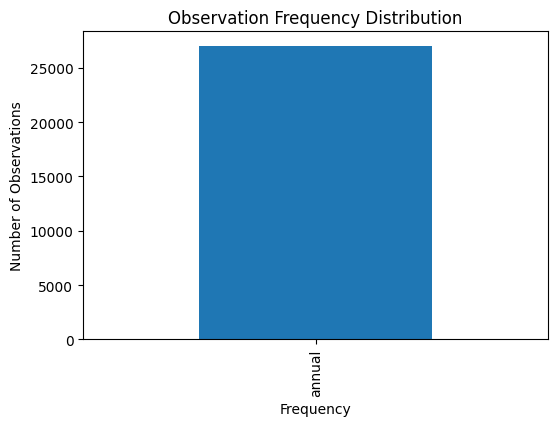

BedrijfstakkenBranchesSBI2008_CategoryGroupID
3     5670
24    5670
7     4320
4     1350
12    1350
6      810
17     810
11     810
14     810
10     810
16     810
22     810
13     540
1      270
15     270
8      270
9      270
18     270
19     270
20     270
21     270
23     270
Name: count, dtype: Int64

In [20]:
# --------------------------------
# Dataset overview
# --------------------------------

# 1. Dataset size
print("Rows:", df_85918NED_clean.shape[0])
print("Columns:", df_85918NED_clean.shape[1])


# 2. Time coverage
print("\nTime coverage:")
print("Start:", df_85918NED_clean["period_enddate"].min())
print("End:", df_85918NED_clean["period_enddate"].max())


# 3. Frequency distribution
print("\nFrequency distribution:")
print(df_85918NED_clean["frequency"].value_counts())


# 4. Worker type distribution
print("\nWorker type distribution:")
print(df_85918NED_clean["TypeWerkenden_Title"].value_counts())


# 5. Gender coverage
print("\nGender distribution:")
print(df_85918NED_clean["Geslacht_Title"].value_counts())

print("\nGender categories:")
print(df_85918NED_clean["Geslacht_Title"].unique())


# 6. Industry coverage
print("\nNumber of industries:")
print(df_85918NED_clean["BedrijfstakkenBranchesSBI2008_Title"].nunique())

print("\nExample industries:")
print(
    df_85918NED_clean["BedrijfstakkenBranchesSBI2008_Title"]
    .unique()[:10]
)


# 7. Missing values overview
print("\nMissing values per column:")
print(df_85918NED_clean.isna().sum().sort_values(ascending=False))


# 8. Frequency visualization
plt.figure(figsize=(6,4))
df_85918NED_clean["frequency"].value_counts().plot(kind="bar")
plt.title("Observation Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Observations")
plt.show()


# 9. Worker type × Gender structure
df_85918NED_clean.groupby(
    ["TypeWerkenden_Title", "Geslacht_Title"],
    observed=False
).size()


df_85918NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"].value_counts()

#### Interpretation (Dataset Overview)

The dataset contains 27,000 observations and 28 variables, covering the period 1995–2024 with annual frequency. The table provides labour market indicators from the Dutch National Accounts broken down by industry, gender, and type of worker.

The dataset forms a balanced structure across the key dimensions year × industry × worker type × gender. Worker types are equally distributed across total workers, employees, and self-employed, while gender categories include total population, men, and women.

The dataset includes 100 industry categories based on the SBI 2008 classification, organized hierarchically from aggregated sectors (e.g., All economic activities) to detailed industries (e.g., Food manufacturing).

Four key labour indicators are available:

WerkzamePersonen – number of employed persons

Banen – number of jobs

Arbeidsjaren – full-time equivalent labour volume (FTE)

GewerkteUren – total hours worked

Missing values are limited (540 observations) and occur consistently across the four labour indicators, which likely reflects undefined combinations of industry, worker type, and gender in the source data.

Overall, the dataset provides a comprehensive and well-structured view of labour market composition in the Netherlands, making it suitable for analysing labour exposure across sectors, which is relevant for modelling sickness absence patterns.

### Labour market evolution over time

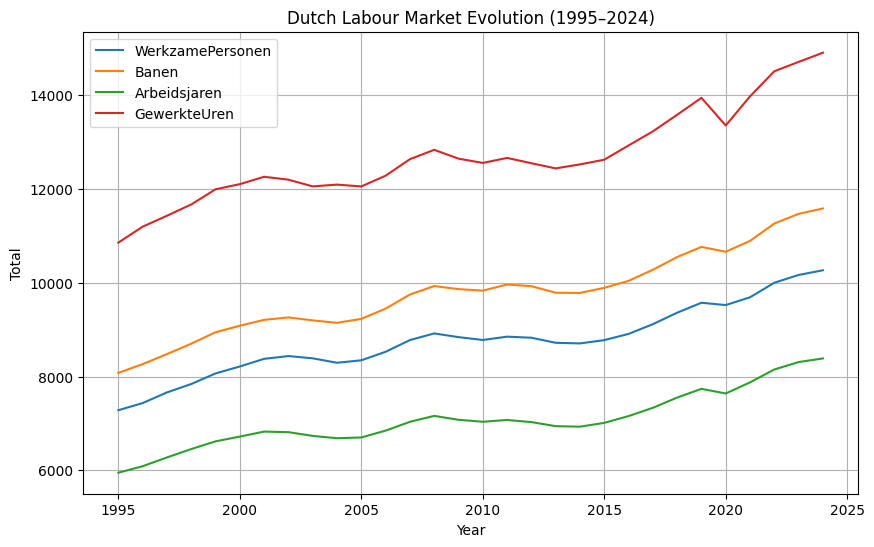

In [21]:
# -----------------------------
# Labour market evolution over time
# -----------------------------

labour_trend = (
    df_85918NED_clean
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .query("BedrijfstakkenBranchesSBI2008_Title == 'A-U Alle economische activiteiten'")
    .groupby("year")[[
        "WerkzamePersonen",
        "Banen",
        "Arbeidsjaren",
        "GewerkteUren"
    ]]
    .sum()
)

plt.figure(figsize=(10,6))

for col in labour_trend.columns:
    plt.plot(labour_trend.index, labour_trend[col], label=col)

plt.title("Dutch Labour Market Evolution (1995–2024)")
plt.xlabel("Year")
plt.ylabel("Total")
plt.legend()
plt.grid(True)

plt.show()

#### Insight — Labour Market Evolution (1995–2024)

The Dutch labour market shows a clear long-term expansion between 1995 and 2024 across all four labour indicators.

Key observations:

1. Steady long-term growth

The number of employed persons increased from roughly 7.3 million to over 10.3 million.

The number of jobs grew from about 8.1 million to more than 11.5 million.

This indicates substantial labour market expansion over the past three decades.

2. Structural difference between jobs and workers

Throughout the period, the number of jobs is consistently higher than the number of workers, suggesting that some individuals hold multiple jobs simultaneously. This reflects increasing labour market flexibility.

3. Labour volume growth

Both:

Arbeidsjaren (FTE labour years)

Gewerkte uren (hours worked)

show similar long-term trends, indicating that total labour input has increased alongside employment growth.

4. Economic cycles are visible

Two periods of slower growth are visible:

2008–2013: impact of the global financial crisis

2020: temporary decline associated with the COVID-19 pandemic

After both periods, the labour market recovered and continued expanding.

5. Structural increase in labour demand

The simultaneous growth of:

workers

jobs

labour years

hours worked

suggests structural growth in labour demand in the Dutch economy.

### Workforce composition over time

C:\Users\gebruiker\AppData\Local\Temp\ipykernel_8900\1487254850.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_85918NED_clean


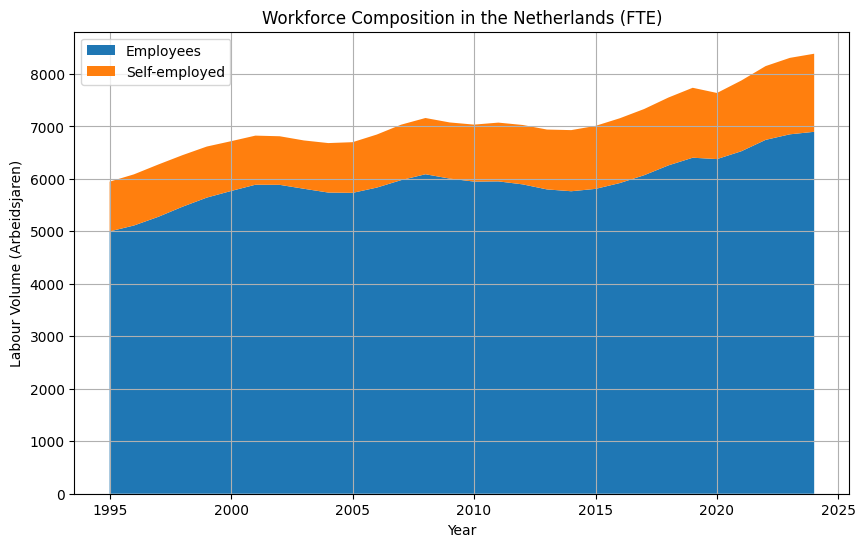

In [24]:
# -----------------------------
# Workforce composition over time
# -----------------------------

workforce = (
    df_85918NED_clean
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("BedrijfstakkenBranchesSBI2008_Title == 'A-U Alle economische activiteiten'")
    .query("TypeWerkenden_Title != 'Totaal'")
    .pivot_table(
        index="year",
        columns="TypeWerkenden_Title",
        values="Arbeidsjaren",
        aggfunc="sum"
    )
)

plt.figure(figsize=(10,6))

plt.stackplot(
    workforce.index,
    workforce["Werknemers"],
    workforce["Zelfstandigen"],
    labels=["Employees", "Self-employed"]
)

plt.title("Workforce Composition in the Netherlands (FTE)")
plt.xlabel("Year")
plt.ylabel("Labour Volume (Arbeidsjaren)")
plt.legend()
plt.grid(True)

plt.show()

#### Insights - Workforce Composition: Employees vs Self-Employed

The Dutch labour market is dominated by employees, who account for the majority of labour volume (measured in full-time equivalent labour years). However, the number of self-employed workers increased noticeably between the late 1990s and the late 2000s, reflecting a shift toward more flexible labour arrangements.

Following the global financial crisis, growth in self-employment slowed and stabilized for several years before increasing again in the late 2010s. Despite this growth, employees continue to represent the largest share of total labour input.

This distinction is important for analysing sickness absence patterns, as employees and self-employed workers face different institutional conditions and incentives regarding sick leave.

### Gender Composition of the Workforce

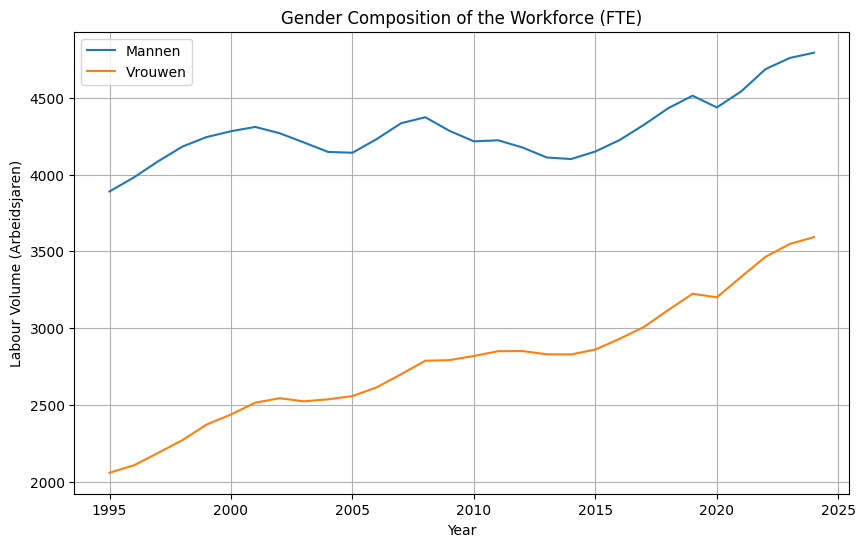

In [26]:
gender_trend = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_Title == 'A-U Alle economische activiteiten'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .pivot_table(
        index="year",
        columns="Geslacht_Title",
        values="Arbeidsjaren",
        aggfunc="sum",
        observed=False
    )
)

# remove total column
gender_trend = gender_trend.drop(columns=["Totaal mannen en vrouwen"])


plt.figure(figsize=(10,6))

for col in gender_trend.columns:
    plt.plot(gender_trend.index, gender_trend[col], label=col)

plt.title("Gender Composition of the Workforce (FTE)")
plt.xlabel("Year")
plt.ylabel("Labour Volume (Arbeidsjaren)")
plt.legend()
plt.grid(True)

plt.show()

#### Interpretation - gender composition of the Dutch labour market

The gender composition of the Dutch labour market has changed notably over time. While male labour volume has grown moderately since the mid-1990s, female labour volume has increased much more strongly. This reflects the continued rise in female labour market participation in the Netherlands. Despite this growth, men still account for a larger share of total labour volume throughout the period.

### Industry Composition

In [28]:
for level, group in hierarchy.groupby("BedrijfstakkenBranchesSBI2008_CategoryGroupID"):
    
    print(f"\nLEVEL {level}")
    print("-" * 40)
    
    for title in sorted(group["BedrijfstakkenBranchesSBI2008_Title"].unique()):
        print(title)


LEVEL 1
----------------------------------------
A-U Alle economische activiteiten

LEVEL 10
----------------------------------------
41 Algemene bouw en projectontwikkeling
42 Grond-, water- en wegenbouw
43 Gespecialiseerde bouw

LEVEL 11
----------------------------------------
45 Autohandel en -reparatie
46 Groothandel en handelsbemiddeling
47 Detailhandel (niet in auto's)

LEVEL 12
----------------------------------------
49 Vervoer over land
50 Vervoer over water
51 Vervoer door de lucht
52 Opslag, dienstverlening voor vervoer
53 Post en koeriers

LEVEL 13
----------------------------------------
58 Uitgeverijen
61 Telecommunicatie

LEVEL 14
----------------------------------------
64 Bankwezen
65 Verzekeraars en pensioenfondsen
66 Overige financiële dienstverlening

LEVEL 15
----------------------------------------
68 Verhuur en handel van onroerend goed

LEVEL 16
----------------------------------------
71 Architecten-, ingenieursbureaus e.d.
72 Research
73 Reclamewezen en mark

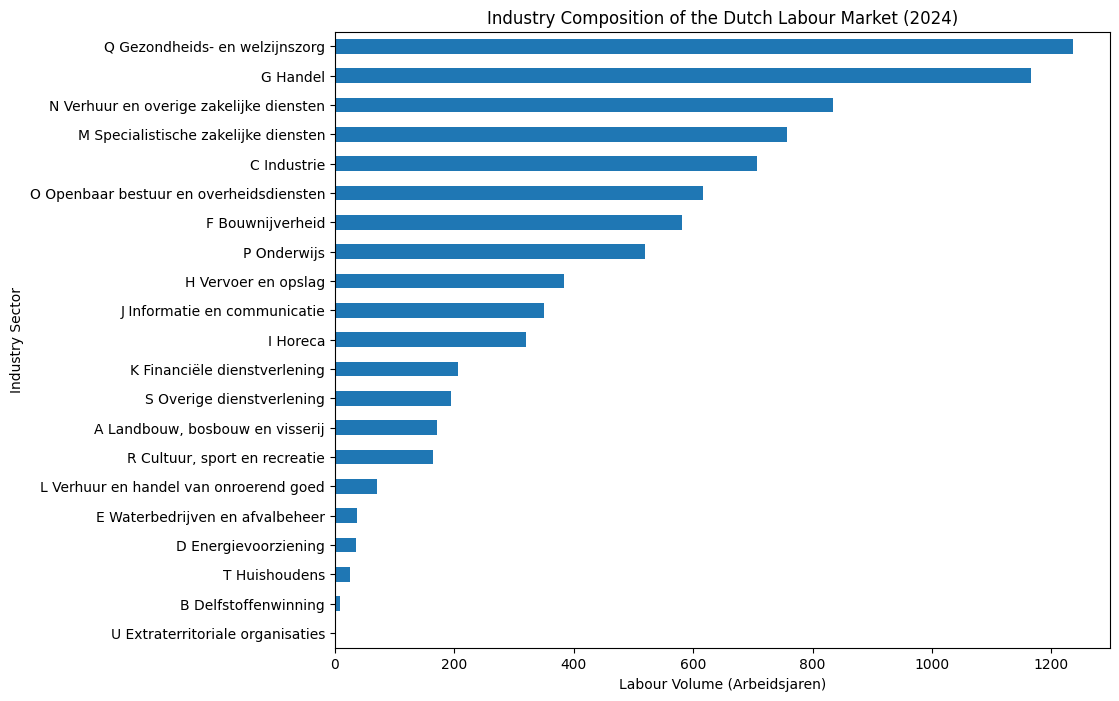

In [29]:
# -----------------------------
# Industry composition (sector level)
# -----------------------------

industry_sector = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'")
    .query("BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'")
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .query("year == 2024")
)

sector_size = (
    industry_sector
    .groupby("BedrijfstakkenBranchesSBI2008_Title", observed=False)["Arbeidsjaren"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

sector_size.plot(kind="barh")

plt.title("Industry Composition of the Dutch Labour Market (2024)")
plt.xlabel("Labour Volume (Arbeidsjaren)")
plt.ylabel("Industry Sector")

plt.show()

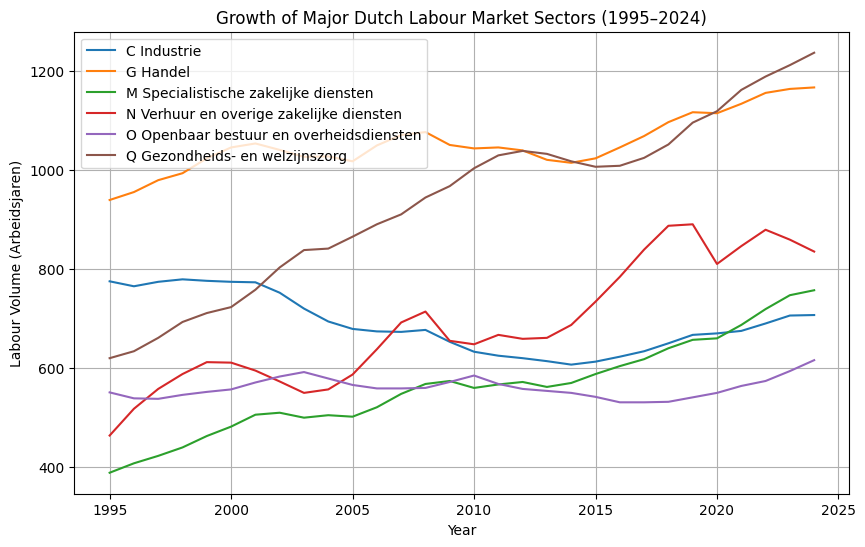

In [31]:
# largest sectors in 2024

top_sectors = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'")
    .query("BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'")
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .query("year == 2024")
    .groupby("BedrijfstakkenBranchesSBI2008_Title", observed=False)["Arbeidsjaren"]
    .sum()
    .nlargest(6)
    .index
)
sector_trend = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'")
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .query("BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'")
    .query("BedrijfstakkenBranchesSBI2008_Title in @top_sectors")
    .pivot_table(
        index="year",
        columns="BedrijfstakkenBranchesSBI2008_Title",
        values="Arbeidsjaren",
        aggfunc="sum",
        observed=False
    )
)

plt.figure(figsize=(10,6))

for col in sector_trend.columns:
    plt.plot(sector_trend.index, sector_trend[col], label=col)

plt.title("Growth of Major Dutch Labour Market Sectors (1995–2024)")
plt.xlabel("Year")
plt.ylabel("Labour Volume (Arbeidsjaren)")
plt.legend()
plt.grid(True)

plt.show()


#### Insight - Industry Composition
Industry Hierarchy Structure

The dataset follows the SBI 2008 industry classification, which organizes economic activities in a hierarchical structure. At the top level, the dataset contains the total economy (A–U), which aggregates all sectors. Below this, the main sector level (CategoryGroupID = 3) represents the primary economic sectors such as agriculture, manufacturing, trade, healthcare, and public administration. These sectors form the most appropriate level for sector comparison because they are mutually exclusive and cover the entire economy.

Further levels represent more detailed industry breakdowns (e.g., divisions and sub-industries) or aggregated industry groups that combine several related activities. While these deeper levels provide more granular industry detail, they may overlap with aggregated categories. For this reason, the analysis focuses primarily on the sector level (Level 3) to avoid double counting and ensure consistent comparisons.

Insights from Industry Composition (2024)

The sector composition graph shows that the Dutch labour market is strongly service-oriented. Healthcare and social services represent the largest sector, followed by trade, administrative and support services, and professional services. Traditional sectors such as manufacturing and construction still employ a substantial share of the workforce but are smaller compared with the largest service sectors.

Insights from Sector Growth (1995–2024)

Over the past three decades, several sectors have experienced significant growth, particularly healthcare and business services, reflecting structural changes in the Dutch economy. Manufacturing has grown more modestly, while trade has remained a consistently large sector. Overall, the results highlight a long-term shift toward service-driven employment growth.

### Gender distribution across industries

<Figure size 1000x800 with 0 Axes>

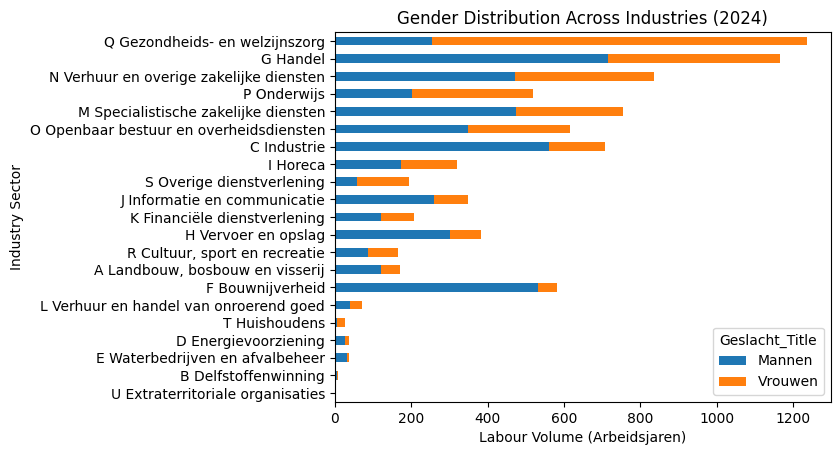

In [33]:
# -----------------------------
# Gender distribution by sector
# -----------------------------

gender_sector = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'")
    .query("BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .query("year == 2024")
    .query("Geslacht_Title != 'Totaal mannen en vrouwen'")
    .pivot_table(
        index="BedrijfstakkenBranchesSBI2008_Title",
        columns="Geslacht_Title",
        values="Arbeidsjaren",
        aggfunc="sum",
        observed=False
    )
)

gender_sector = gender_sector.sort_values("Vrouwen")

gender_sector = gender_sector.drop(columns=["Totaal mannen en vrouwen"], errors="ignore")

plt.figure(figsize=(10,8))

gender_sector.plot(
    kind="barh",
    stacked=True
)

plt.title("Gender Distribution Across Industries (2024)")
plt.xlabel("Labour Volume (Arbeidsjaren)")
plt.ylabel("Industry Sector")

plt.show()

#### Interpretation - Gender Distribution Across Industries


The gender composition of employment varies substantially across sectors in the Dutch labour market. Healthcare and social services, education, and several administrative service sectors employ a relatively large share of women, while construction, manufacturing, and transport are strongly male-dominated.

Some sectors, such as trade and professional services, show a more balanced gender distribution. These differences reflect structural labour market patterns related to occupational specialization, working conditions, and historical labour participation trends.

Understanding these sectoral gender differences is important for labour market analysis, as working conditions and sickness absence patterns often vary across both industries and gender groups.

### Employee vs Self-Employed distribution across industries

<Figure size 1000x800 with 0 Axes>

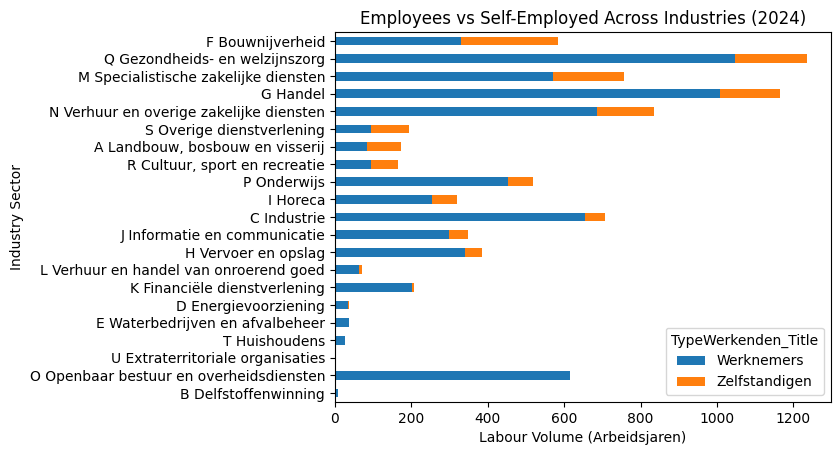

In [35]:
# -----------------------------
# Worker type distribution by sector
# -----------------------------

worker_sector = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'")
    .query("BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'")
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("year == 2024")
    .query("TypeWerkenden_Title != 'Totaal'")
    .pivot_table(
        index="BedrijfstakkenBranchesSBI2008_Title",
        columns="TypeWerkenden_Title",
        values="Arbeidsjaren",
        aggfunc="sum",
        observed=False
    )
)

worker_sector = worker_sector.sort_values("Zelfstandigen")
worker_sector = worker_sector.drop(columns=["Totaal"], errors="ignore")

plt.figure(figsize=(10,8))

worker_sector.plot(
    kind="barh",
    stacked=True
)

plt.title("Employees vs Self-Employed Across Industries (2024)")
plt.xlabel("Labour Volume (Arbeidsjaren)")
plt.ylabel("Industry Sector")

plt.show()

#### Employees vs Self-Employed Across Industries

The distribution of employees and self-employed workers varies significantly across sectors in the Dutch labour market. Sectors such as healthcare, education, public administration, and manufacturing are largely dominated by employees, reflecting more formal employment structures and institutional arrangements.

In contrast, sectors like construction, agriculture, and professional services show a relatively higher share of self-employed workers. These sectors often involve project-based work, independent contracting, or small business ownership, which contributes to higher levels of self-employment.

Understanding these sectoral differences is important for labour market analysis because self-employed workers are typically subject to different institutional conditions regarding social protection and sickness insurance compared to employees.

### Labour Intensity Across Industries

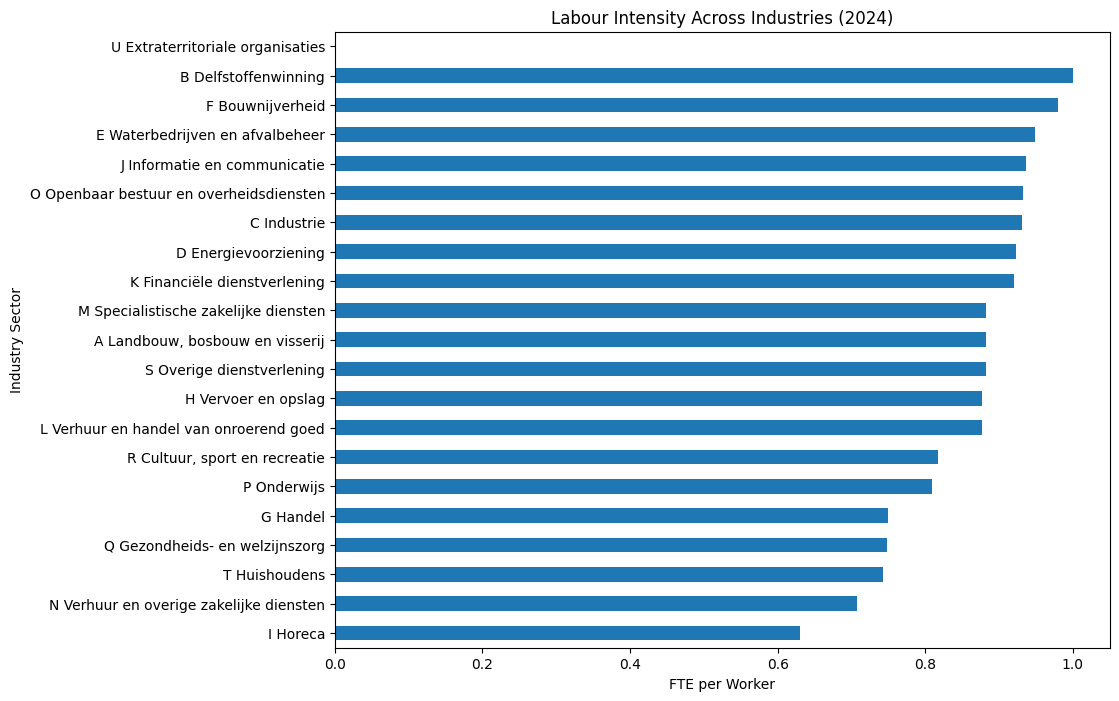

In [36]:
# -----------------------------
# Labour intensity (FTE per worker)
# -----------------------------

labour_intensity = (
    df_85918NED_clean
    .query("BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'")
    .query("BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'")
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .query("year == 2024")
    .groupby("BedrijfstakkenBranchesSBI2008_Title", observed=False)[
        ["WerkzamePersonen", "Arbeidsjaren"]
    ]
    .sum()
)

labour_intensity["FTE_per_worker"] = (
    labour_intensity["Arbeidsjaren"] /
    labour_intensity["WerkzamePersonen"]
)

labour_intensity = labour_intensity.sort_values("FTE_per_worker")

plt.figure(figsize=(10,8))

labour_intensity["FTE_per_worker"].plot(kind="barh")

plt.title("Labour Intensity Across Industries (2024)")
plt.xlabel("FTE per Worker")
plt.ylabel("Industry Sector")

plt.show()

#### Insight - Labour Intensity Across Industries

The labour intensity indicator (FTE per worker) shows how much of the workforce is employed full-time versus part-time across industries. Sectors such as construction, mining, and energy show values close to 1, indicating that most workers are employed in full-time positions. In contrast, sectors such as hospitality, business services, and household services show lower labour intensity, suggesting a higher prevalence of part-time work. This pattern aligns with known characteristics of the Dutch labour market, where service sectors often rely more heavily on flexible and part-time employment.

Key Takeaways

Construction and industrial sectors → mostly full-time employment

Hospitality and service sectors → higher share of part-time workers

Public services and education → moderate labour intensity (mix of full- and part-time work)

### Sector Gender vs Part-Time Structure

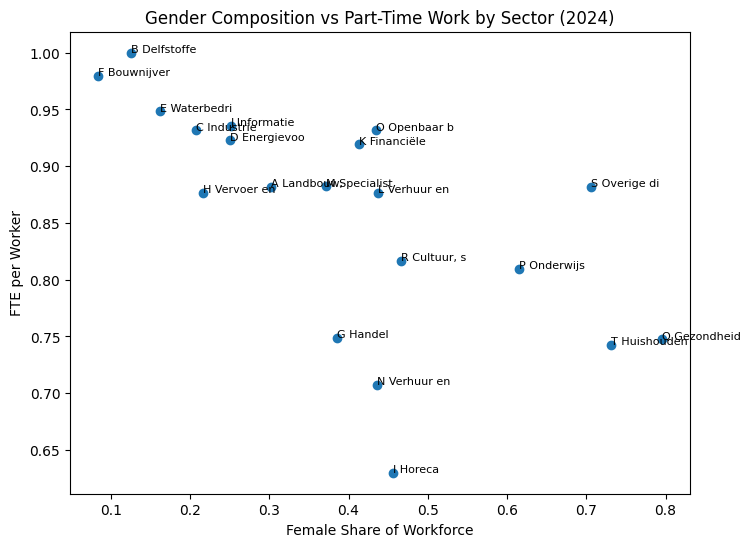

In [37]:
# -----------------------------
# Gender vs Part-time structure by sector
# -----------------------------

data = df_85918NED_clean.query(
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'"
)

data = data.query(
    "BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'"
)

data_2024 = data.query("year == 2024")

# Total FTE per sector
fte_total = (
    data_2024
    .query("Geslacht_Title == 'Totaal mannen en vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .set_index("BedrijfstakkenBranchesSBI2008_Title")
)

# Female FTE
fte_female = (
    data_2024
    .query("Geslacht_Title == 'Vrouwen'")
    .query("TypeWerkenden_Title == 'Totaal'")
    .set_index("BedrijfstakkenBranchesSBI2008_Title")
)

analysis = pd.DataFrame({
    "FTE_total": fte_total["Arbeidsjaren"],
    "FTE_female": fte_female["Arbeidsjaren"],
    "workers": fte_total["WerkzamePersonen"]
})

analysis["female_share"] = analysis["FTE_female"] / analysis["FTE_total"]
analysis["fte_per_worker"] = analysis["FTE_total"] / analysis["workers"]

analysis = analysis.dropna()

plt.figure(figsize=(8,6))

plt.scatter(
    analysis["female_share"],
    analysis["fte_per_worker"]
)

for sector in analysis.index:
    plt.text(
        analysis.loc[sector,"female_share"],
        analysis.loc[sector,"fte_per_worker"],
        sector[:12],
        fontsize=8
    )

plt.xlabel("Female Share of Workforce")
plt.ylabel("FTE per Worker")
plt.title("Gender Composition vs Part-Time Work by Sector (2024)")

plt.show()

#### Insight -  Sector Gender vs Part-Time Structure

The relationship between gender composition and labour intensity reveals a structural pattern across sectors. Industries with a higher share of female workers, such as healthcare, education, and hospitality, tend to have lower FTE per worker, indicating a higher prevalence of part-time employment. In contrast, male-dominated sectors such as construction, mining, energy, and transport exhibit higher labour intensity, meaning that workers are more likely to be employed in full-time positions. This pattern highlights how sectoral specialization and gender composition jointly influence employment structures in the Dutch labour market.

Why This Insight Matters for the UWV Project

This pattern helps explain structural differences in labour market vulnerability:

Part-time heavy sectors → often more flexible labour markets

Full-time industrial sectors → different absence and sickness patterns

Care sector → large workforce + high part-time → critical for sickness modelling


### Sector Contribution to Labour Market Growth

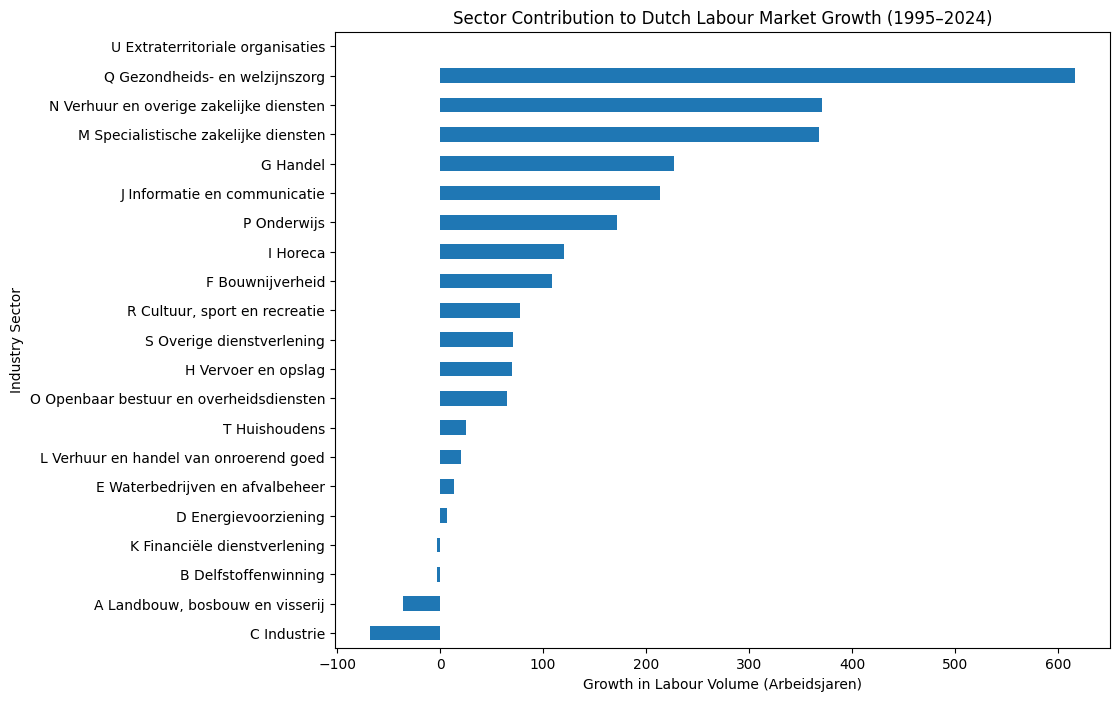

In [38]:
# -----------------------------
# Sector contribution to labour market growth
# -----------------------------

growth_data = df_85918NED_clean.query(
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID == '3'"
)

growth_data = growth_data.query(
    "BedrijfstakkenBranchesSBI2008_Title != 'A-U Alle economische activiteiten'"
)

growth_data = growth_data.query(
    "Geslacht_Title == 'Totaal mannen en vrouwen'"
)

growth_data = growth_data.query(
    "TypeWerkenden_Title == 'Totaal'"
)

# FTE in 1995
fte_1995 = (
    growth_data.query("year == 1995")
    .set_index("BedrijfstakkenBranchesSBI2008_Title")["Arbeidsjaren"]
)

# FTE in 2024
fte_2024 = (
    growth_data.query("year == 2024")
    .set_index("BedrijfstakkenBranchesSBI2008_Title")["Arbeidsjaren"]
)

growth = pd.DataFrame({
    "FTE_1995": fte_1995,
    "FTE_2024": fte_2024
})

growth["growth"] = growth["FTE_2024"] - growth["FTE_1995"]

growth = growth.sort_values("growth")

# Plot
plt.figure(figsize=(10,8))

growth["growth"].plot(kind="barh")

plt.title("Sector Contribution to Dutch Labour Market Growth (1995–2024)")
plt.xlabel("Growth in Labour Volume (Arbeidsjaren)")
plt.ylabel("Industry Sector")

plt.show()

#### Insight - Sector Contribution to Labour Market Growth

The Dutch labour market has experienced substantial structural change over the past three decades, with growth concentrated in service-oriented sectors. Healthcare and welfare services show by far the largest increase in labour volume, followed by business services and specialized professional services. Other expanding sectors include trade, information and communication, and education, reflecting the increasing importance of knowledge-intensive and service-based activities in the economy. In contrast, traditional sectors such as industry and agriculture exhibit stagnation or decline in labour volume, highlighting the long-term shift away from production-based sectors toward a service-driven labour market.

Why This Matters for  UWV Project

This insight is important because sectors that expanded strongly also tend to:

employ large workforces

rely more on part-time work

have higher gender diversity

show different sickness absence patterns

Therefore, understanding sectoral labour growth helps contextualize future absenteeism prediction models.

# Summary and Key Insights

Dataset Overview

This notebook explored the CBS labour market dataset 85918NED, which provides annual labour market indicators for the Netherlands between 1995 and 2024.

The dataset measures labour volume across economic sectors, gender, and worker types, using national accounts data.

The main indicators analysed were:

WerkzamePersonen – number of employed persons

Banen – number of jobs

Arbeidsjaren – full-time equivalent labour volume (FTE)

GewerkteUren – total hours worked

These indicators were analysed across:

time (1995–2024)

gender (Mannen vs Vrouwen)

worker type (Werknemers vs Zelfstandigen)

industry sectors (SBI 2008 classification)

The analysis focused on understanding labour market structure, sectoral composition, gender participation, and long-term labour market shifts.

Key Insights
1. Long-term expansion of the Dutch labour market

The Dutch labour market expanded substantially between 1995 and 2024, with steady increases in:

employment (WerkzamePersonen)

number of jobs (Banen)

labour volume (Arbeidsjaren)

total hours worked (GewerkteUren)

Although temporary declines occurred during economic shocks (e.g., early 2000s slowdown and the COVID-19 period), the long-term trend shows consistent labour market growth.

Implication for modelling

Changes in overall labour demand and labour market tightness may influence sickness and absenteeism patterns.

2. Structural shift toward a service-based economy

Sectoral analysis shows that labour market growth has been concentrated in service-oriented sectors.

The largest contributors to employment growth were:

Healthcare and welfare services

Business services

Specialized professional services

Trade

Information and communication

In contrast, traditional sectors such as:

Industry

Agriculture

Mining

showed slower growth or declining labour volumes.

Implication

Sectoral composition is an important structural factor influencing labour market dynamics and working conditions.

3. Increasing female participation in the labour market

Both male and female employment increased over the analysed period, but female employment grew faster, gradually narrowing the gender gap.

Several expanding sectors — particularly healthcare, education, and services — show high female labour participation.

Implication

Gender composition is an important labour market dimension that may influence working patterns and absenteeism behaviour.

4. Strong sectoral differences in labour structure

The analysis revealed large differences between sectors in terms of labour intensity and workforce composition.

For example:

Construction, mining, and energy sectors show higher labour intensity, indicating predominantly full-time employment.

Hospitality, healthcare, and education sectors show lower labour intensity, reflecting a larger share of part-time work.

These structural differences reflect sector-specific working patterns and labour demand characteristics.

Implication

Sectoral labour characteristics should be considered when analysing labour market behaviour and workforce dynamics.

5. Clear relationship between gender composition and part-time work

Combining sectoral and gender analysis revealed a strong pattern:

Sectors with higher female participation tend to show lower FTE per worker, indicating more part-time employment.

Male-dominated sectors tend to exhibit higher labour intensity, with workers more likely to work full-time.

This pattern is characteristic of the Dutch labour market and reflects the interaction between sector structure, gender composition, and employment patterns.

Implication

Gender composition and part-time structures are key contextual variables when analysing labour market outcomes.

Potential Features for Sick Leave Prediction

The indicators explored in this dataset can support modelling by providing macro-level labour market context, such as:

Labour market scale

total employment

labour volume (FTE)

total hours worked

Sectoral structure

employment distribution across industries

sector growth trends

Workforce composition

gender participation by sector

worker type distribution (employees vs self-employed)

Labour intensity

FTE per worker

differences in full-time vs part-time employment patterns

Conclusion

The analysis shows that the Dutch labour market has undergone significant structural changes over the past three decades, characterized by steady employment growth, expanding service sectors, increasing female labour participation, and strong sectoral differences in labour intensity.

These structural labour market indicators provide valuable context for understanding workforce dynamics and may support future sick leave prediction models, as they capture macro-economic and sectoral conditions that influence employment patterns and working environments.